# <font style="color:blue">Table of Content</font>

- [Fix Random Seed](#seed)
- [Use a Simple Baseline Model](#simple-model)
- [Turn-off  Data Augmentation](#data-aug)
- [Visualize Input Data Before It Goes Inside the Network](#vis)
- [Check Initial Loss and Accuracy](#init-loss)
- [Does Loss Goes Down at Every Epoch?](#per-epoch-loss)
- [Forward the Same Batch for Multiple Interations and Check if Loss Drops Near to 0](#loss-to-0)
- [Forward Pass a Zero Input and Check If Loss is High](#zero-input)
- [Calculate the Loss on Entire Test-Set](#loss-testset)
- [Check Dimensions Using Backprop](#backprop)
- [Reference](#refs)

# <font style="color:blue">Check Training Pipeline</font>


Some aspects of the Training Pipeline have already been discussed in one of our videos on `Training Deep Networks`.

**Points written in code:**

In [2]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

 ## <font style="color:green">1. Fix Random Seed</font><a name="seed"></a>

We deal with only one numeric computational library i.e. PyTorch. So we'll set its random seed. 

The code follows:

In [3]:
torch.manual_seed(0)

 ## <font style="color:green">2. Use a Simple Baseline Model</font><a name="simple-model"></a>

Here, we shall use a simple dataset to discuss 10 points.. This dataset is a small subset of the `Caltech-101` data. You can download the data from http://www.vision.caltech.edu/Image_Datasets/Caltech101/


This subset data spans 4 classes i.e. `[chandelier, watch, laptop, motorbike]`, having around 400 images.

Use a simple Image Classification network, which has  few convolutional and linear layers. The input size will be `(3, 160, 160)` and the output nodes `4`.

Let's define a simple model in the following block.

In [4]:
class Net(nn.Module):
    def __init__(self,n_classes):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.conv3 = nn.Conv2d(64, 32, 3, 1)
        self.conv4 = nn.Conv2d(32, 32, 3, 1)
        self.fc1 = nn.Linear(10368, 2048)
        self.fc2 = nn.Linear(2048,128)
        self.fc3 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

 ## <font style="color:green">3. Turn-off  Data Augmentation</font><a name="data-aug"></a>

Sometimes, we use augmentation techniques, such as random-rotation, adding small noise, translating the image etc. But when we  ensure reproducibility, we do not need such techniques. Only use Resizing, Cropping and Normalization as they are deterministic.

The images in the data are of various sizes. We whereas the model  fix the input size to `(160,160)`, in line with what our model expects.


We will also need a generator to  supply the batch of images required for training. PyTorch provides a good handle for this as well. Don't worry if you don't understand the code below. It takes care of the preprocessing step (without any augmentation), and gives us the data-generator that we must feed to the neural network. At this point, you need not know beyond this. More on the code in later lectures.

In [6]:
from torchvision import datasets, transforms

preprocess = transforms.Compose([transforms.Resize((196,196)),transforms.CenterCrop((160,160)),
                                 transforms.ToTensor()])

data_root = "./data/caltech_subset"
    
train_data_path = os.path.join(data_root, 'train')
test_data_path = os.path.join(data_root, 'test')


train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder(root=train_data_path, transform=preprocess),
    batch_size=16,
    shuffle=True,
    num_workers=2)



test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder(root=test_data_path, transform=preprocess),
    batch_size=16,
    shuffle=False,
    num_workers=2
)

 ## <font style="color:green">4. Visualize Input Data Before It Goes Inside the Network</font><a name="vis"></a>

This step ensures the input goes inside the network as expected. It's just a sanity-check. Use image-visualizing libraries like `PIL`, `OpenCV` or `Matplotlib` to do this. And  the train_loader to  get batches of images. Pick some samples and plot them. Omit  `transforms.Normalize()`, if you plan using it in the pre-processing step. Because if there is normalization,, the pixel values will not be in the range of `0-255`.


Follow  this code to visualize some of the images:

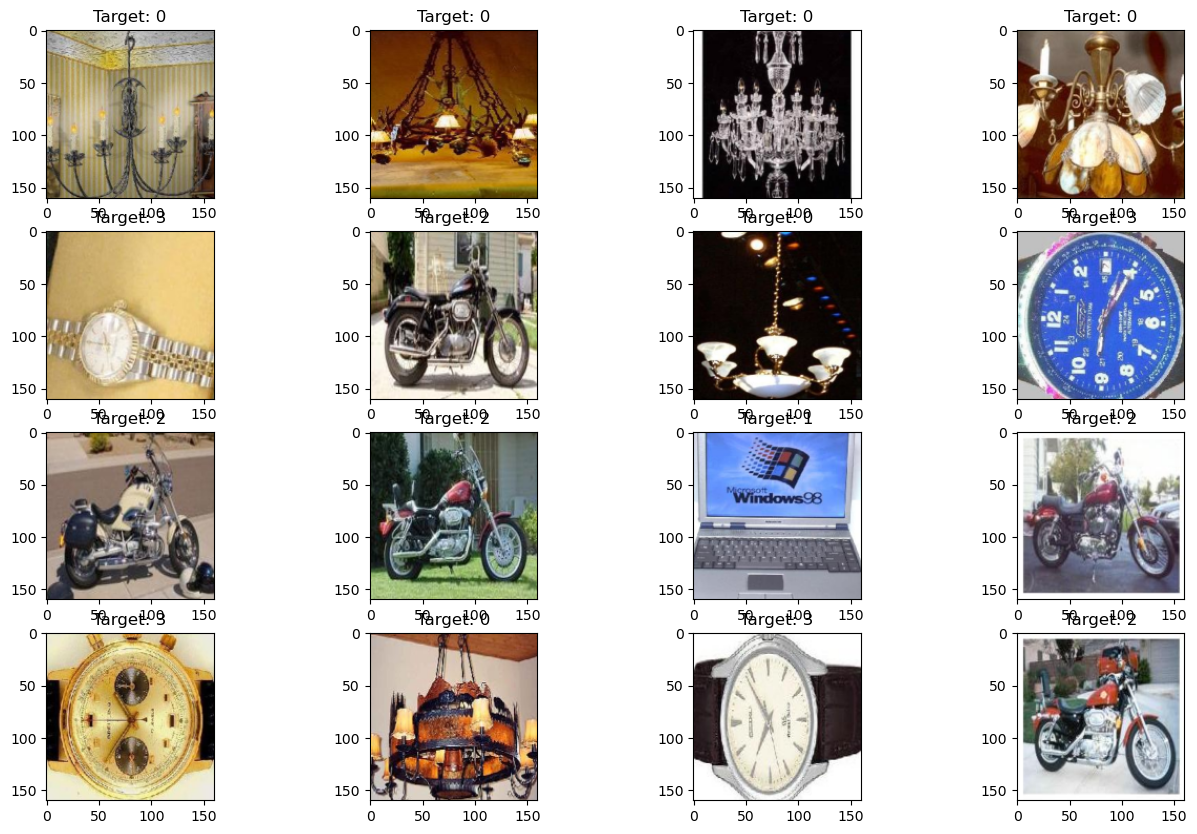

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16, 10)
plt.figure
for images, labels in train_loader:
    for i in range(len(labels)):
        plt.subplot(4, 4, i+1)
        img = transforms.functional.to_pil_image(images[i])
        plt.imshow(img)
        plt.gca().set_title('Target: {0}'.format(labels[i]))
    plt.show()
    break

   ## <font style="color:green">5. Check Initial Loss and Accuracy</font><a name="init-loss"></a>

**Is the model initialized randomly?** Verify. The **initial loss** should be around `log(num_classes)` and **accuracy** about  `1/num_classes`.

Now,create a class `CheckInitLossAndAccuracy` and  verify the `5th` point, by calculating the loss and accuracy. You  will need the following arguments:


We will need the following arguments:-
1. A randomly initialized model.
2. A batch of input.
3. A batch of  target classes.
4. Number of classes.


The class has two methods:
- `verify_init_loss` verifies if the initial loss is around `log(num_classes)`

- `verify_init_accuracy` verifies if the initial accuracy is around `1/num_classes`

In [12]:
class CheckInitLossAndAccuracy():
    def __init__(self, net, x, num_classes, target = None):
        self.net = net
        self.x = x
        self.num_classes = num_classes
        self.criterion = nn.CrossEntropyLoss()
        self.batch_size = self.x.size()[0]
        if target is None:
            self.target = torch.randint(0, self.num_classes, size=(self.batch_size,))
        else:
            self.target = target
        self.logits = self.net(self.x)

    def verify_init_loss(self):
        loss = self.criterion(self.logits, self.target)
        print("Expected loss is log(num_classes) : ", np.log(self.num_classes))
        print("Inferred loss is ce loss :", loss.item())
        return None

    def verify_init_accuracy(self):
        predictions = torch.argmax(F.softmax(self.logits, dim=1), axis=1)
        accuracy = accuracy_score(self.target, predictions.detach())
        print("Expected accuracy is ", 1 / self.num_classes)
        print("Inferred accuracy is ", accuracy)
        return None


In [13]:
from sklearn.metrics import accuracy_score

n = 4
x, target = next(iter(train_loader))

print("num classes are ", n)
model = Net(n)
check = CheckInitLossAndAccuracy(model, x, n, target)
check.verify_init_loss()
check.verify_init_accuracy()

num classes are  4
Expected loss is log(num_classes) :  1.3862943611198906
Inferred loss is ce loss : 1.3629214763641357
Expected accuracy is  0.25
Inferred accuracy is  0.25


**Look at the numbers, they are almost equal!**

  ## <font style="color:green">6. Does Loss Goes Down at Every Epoch?</font><a name="per-epoch-loss"></a>

Check it out by setting up a training procedure that is typical to  a neural network. Store the loss values in a list or an array. Visualize it once the training gets over.

Follow this code to do this:

In [14]:
import torch.optim as optim

num_classes = 4
model1 = Net(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model1.parameters(), lr=0.001, momentum = 0.9)


loss_list = []
num_epochs = 10
for epoch in range(num_epochs): 
    per_epoch_loss= 0
    for i, data in enumerate(train_loader): 
        optimizer.zero_grad()
        x, target = data
        logits = model1(x)
        loss = criterion(logits, target)
        temp_loss = loss.item()
        per_epoch_loss+=temp_loss
        loss.backward()
        optimizer.step()
        
    per_epoch_avg_loss = per_epoch_loss/(i+1)
    loss_list.append(per_epoch_avg_loss)
    print("Loss at epoch {0} = {1}".format(epoch+1, per_epoch_avg_loss ))

Loss at epoch 1 = 1.3832911550998688
Loss at epoch 2 = 1.3807172328233719
Loss at epoch 3 = 1.3810094346602757
Loss at epoch 4 = 1.3803000450134277
Loss at epoch 5 = 1.378283182779948
Loss at epoch 6 = 1.3785214771827061
Loss at epoch 7 = 1.3765821754932404
Loss at epoch 8 = 1.378222535053889
Loss at epoch 9 = 1.3766127576430638
Loss at epoch 10 = 1.3746051738659542


**You  kept track of the `loss`, at every epoch in the `loss_list`. Let's use them to plot the loss-curve.**

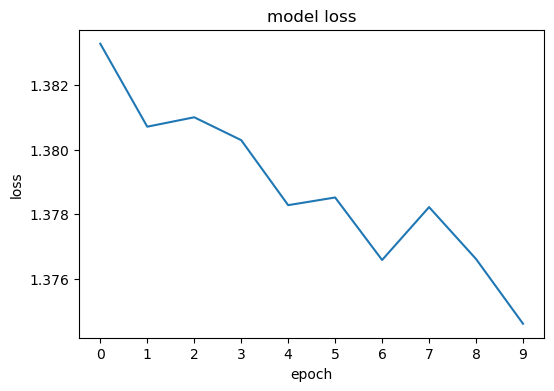

In [15]:
plt.figure(figsize = (6,4))
plt.plot(loss_list)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.xticks(np.arange(0,10))
plt.show()

The loss-curve shows that the loss is indeed plummeting.

  ## <font style="color:green">7. Forward the Same Batch for Multiple Interations and Check if Loss Drops Near to 0 </font><a name="loss-to-0"></a>

Use the above code for this too., Only do not  iterate over the batch. Just forward the same and monitor the loss. 

The code follows:

In [16]:
import torch.optim as optim

num_classes = 4
model2 = Net(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

x, target = next(iter(train_loader))


loss_list = []
num_iters = 25
for i in range(num_iters): 
    optimizer.zero_grad()
    logits = model2(x)
    loss = criterion(logits, target)
    temp_loss = loss.item()
    loss.backward()
    optimizer.step()
    loss_list.append(temp_loss)
    print("Loss at iteration-{} is {}".format(i+1,temp_loss))

Loss at iteration-1 is 1.3891388177871704
Loss at iteration-2 is 1.3617606163024902
Loss at iteration-3 is 1.3666013479232788
Loss at iteration-4 is 1.3253542184829712
Loss at iteration-5 is 1.3079500198364258
Loss at iteration-6 is 1.2562131881713867
Loss at iteration-7 is 1.1696758270263672
Loss at iteration-8 is 1.0327584743499756
Loss at iteration-9 is 0.8504902124404907
Loss at iteration-10 is 0.6343913078308105
Loss at iteration-11 is 0.4525391161441803
Loss at iteration-12 is 0.3801442086696625
Loss at iteration-13 is 0.2041795253753662
Loss at iteration-14 is 0.11826140433549881
Loss at iteration-15 is 0.029764877632260323
Loss at iteration-16 is 0.02194734662771225
Loss at iteration-17 is 0.0025871528778225183
Loss at iteration-18 is 0.010170732624828815
Loss at iteration-19 is 0.004353772383183241
Loss at iteration-20 is 0.0008142212172970176
Loss at iteration-21 is 0.00010712574294302613
Loss at iteration-22 is 1.337293997494271e-05
Loss at iteration-23 is 1.758318035172124e

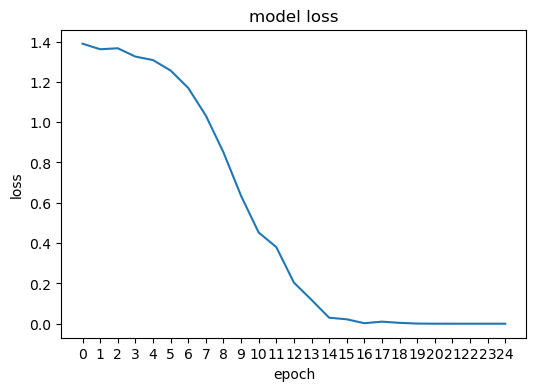

In [17]:
# Let's plot the loss curve.

plt.figure(figsize = (6,4))
plt.plot(loss_list)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.xticks(np.arange(0,i+1))
plt.show()

 ## <font style="color:green">8. Forward Pass a Zero Input and Check If Loss is High</font><a name="zero-input"></a>

For this, we will use a model trained in 6th point i.e. `model1`, and look at the loss. The `input` or `x` to this model will be Tensors of zeros,  and the `target` will be a set of random numbers between `0` and `3`.
We got a final loss of `1.3643`, at the `10th` epoch, in `section-6` , so we expect the randomized input shall produce a much higher loss than this.

In [18]:
criterion = nn.CrossEntropyLoss()

x = torch.zeros(size = (16,3,160,160))
target = torch.randint(0,4,size = (16,))
logits = model1(x)

loss = criterion(logits,target)
print("Loss with zero-valued input is ", loss.item())

Loss with zero-valued input is  1.4058386087417603


  ## <font style="color:green">9. Calculate the Loss on Entire Test-Set </font><a name="loss-testset"></a>

For this, we already have a generator called the `test_loader`. Everytime we want to test our model's performance, we use it. The following code will calculate the test loss, on the entire test set, every 2 epochs. You can however calculate it at every epoch as well. It’s the user who determines how frequently the loss needs to be logged.


Use the code that is given in the `6th` point. Just add, a few extra lines  to calculate the test-loss. Here, it is:

In [13]:
import torch.optim as optim

num_classes = 4
model3 = Net(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.001, momentum=0.9)


loss_list = []
num_epochs = 10
for epoch in range(num_epochs): 
    per_epoch_loss= 0
    for i, data in enumerate(train_loader): 
        optimizer.zero_grad()
        x, target = data
        model3.train()
        logits = model3(x)
        loss = criterion(logits, target)
        temp_loss = loss.item()
        per_epoch_loss+=temp_loss
        loss.backward()
        optimizer.step()
    per_epoch_avg_loss = per_epoch_loss/(i+1)
    loss_list.append(per_epoch_avg_loss)
    print("Traning loss at epoch {} = {}".format(epoch+1, per_epoch_avg_loss ))
    
    if(epoch+1)%2==0:
        total_test_loss = 0
        with torch.no_grad():
            model3.eval()
            for j, test_data in enumerate(test_loader):
                test_x, test_target = test_data
                test_logits = model3(test_x)
                test_loss = criterion(test_logits, test_target)
                total_test_loss+= test_loss.item()
            print("Test loss at epoch {} = {}".format(epoch+1, total_test_loss/(j+1)))
            

Traning loss at epoch 1 = 1.3820062081019084
Traning loss at epoch 2 = 1.3799500167369843
Test loss at epoch 2 = 1.374723732471466
Traning loss at epoch 3 = 1.378374069929123
Traning loss at epoch 4 = 1.3789329131444295
Test loss at epoch 4 = 1.370424509048462
Traning loss at epoch 5 = 1.3776967525482178
Traning loss at epoch 6 = 1.3767632047335308
Test loss at epoch 6 = 1.3675776422023773
Traning loss at epoch 7 = 1.3752888192733128
Traning loss at epoch 8 = 1.375061497092247
Test loss at epoch 8 = 1.3656656444072723
Traning loss at epoch 9 = 1.3762739996115367
Traning loss at epoch 10 = 1.3746218880017598
Test loss at epoch 10 = 1.3627921044826508


## <font style="color:green">10. Check Dimensions Using Backprop</font><a name="backprop"></a>

Let's take a concrete example and break down the points discussed in the video,.

1. Consider a simple network with just a few convolutional and linear layers, whose input shape is `(1,28,28)` and output shape is 10.


2. Take the batch size to be 25. The input size will then be `(25,1,28,28)` and the output `(25,10)`.


3. Once you get  the output, plug it  inside the Loss function to get a loss. Typically, this loss is just one number (a scalar), which is either summed or averaged over the `25` loss values. However, you can get the unsummed and unaveraged loss-values, by passing `reduction='none'`, when instantiating `nn.CrossEntropyLoss()`. Now, if we evaluate the loss, it would not be a scalar, but a vector of `25` entries, where each entry corresponds to the loss for each image in the batch.


4. As discussed in the video, keep only **one entry (eg. `11th` entry)** in this `25-d` loss-vector intact. Set the remaining `24` entries to zero. Then calculate the gradients via backpropagation from this modified loss.


5. After backpropagation, its gradients can be accessed. At this point, note that the gradients should be of size `(25, num_weights)`. Each entry in the first dimension must correspond to the gradients for each image.


We claimed that if the dimensions are right, then all the gradients, except that in the `11th` entry will be zero.  No need to check   the entries for this.  Just sum up the gradients along the batch (first) dimension, and look at the resulting `25` numbers. You will see  that the index with the highest number is `11`, indicating that the gradients at the `11th` entry are non-zero.




If the dimensions are not right, then the index will not be 11.

**NOTE**

In order to verify this claim using code, there is a small bottleneck.

PyTorch expects loss to be scalar, it will throw an error, if a Tensor ( in our case, if a `25-d` vector ) is passed.

And due to this, the gradients which we can access after `loss.backward()` will be of size `(num_weights,)` and not `(25, num_weights)`, i.e. the gradients will be calculated from the sum or average,  over the 25 entries of the loss values.


But no worries, we will show you a work-around for this.


   
Follow these two steps:

**STEP-1** `get_batched_gradients_metric`

1. Follow the same steps, till the `4th` point -.. Keep only the `11th` entry intact. Set the rest to `0`. Then, SUM-THEM-UP. Now,  we have a scalar, which we can easily backprop.

2. After backprop, the gradients are expected to be of size `(num_weights,)`. But we are not sure if these gradients really belonged to the `11th` image. Verify this with an additional step., 

3. Also, let's not look at the whole set of gradients. Instead, consider  the absolute-sum, it will be much easier to compare.


**STEP-2** (as a verification method for step-1 ) `get_individual_gradients_metric`

1. Follow the same steps till the `4th` point. Keeping only the `11th` entry intact. Set the rest to 0. Instead of summing up the loss-vector and bringing it to a scalar, let’s do it in an iterative way for the whole batch.


2. For each image in the batch, we backprop, with its corresponding loss. This essentially means except the `11th` image, all all loss entries will be zero. We will also keep track of the absolute sum of gradients for each image.


3. Once the iteration on the batch is over, we will have `25` such gradient-sums.


In `step-2`,  all  every gradient-sum, except that at the 11th entry will be zero. Also, the non-zero value of the `11th` entry must be exactly equal to the number we get in `step-1`. 

Thus indicating that only the `11th` entry has gradients. This in turn means that the dimensions are correct.



We will use the class `Check_dims_via_backprop` to verify the `10th` point. The class expects the following parameters:


1. Input batch

2. The Network-class

3. Target batch

4. A random number that indicates, which image in the batch we want to experiment with.

Execute two steps to verify the above statement. 

1. The method `get_batched_gradients_metric()` will give us the gradient-sum as mentioned in STEP-1.


2. The method `get_individual_gradients_metric()` will give us the gradient-sum for each image as mentioned in STEP-2

In [53]:
class CheckDimsViaBackprop():
    def __init__(self, net_class, x, num_classes, target=None, which_sample=11):
        self.first_model = None
        self.net_class = net_class
        self.x = x
        self.num_classes = num_classes
        self.batch_size = self.x.size()[0]
        self.which_sample = which_sample
        if target is None:
            self.target = torch.randint(0, self.num_classes, size=(self.batch_size,))
        else:
            self.target = target
        print(self.target.shape)

    def get_batched_gradients_metric(self):
        first_model = self.net_class(self.num_classes)
        self.first_model = first_model
        criterion = nn.CrossEntropyLoss(reduction='none')

        logits = first_model(self.x)
        print(f" logits: {logits.shape} \n{logits}")
        loss = criterion(logits, self.target)
        print(f" loss: {loss}")

        mask = torch.zeros_like(loss)
        mask[self.which_sample] = 1
        print(f"mask : {mask}")
        loss *= mask
        print(f" loss: {loss}")
        loss = loss.sum()
        print(f" sum loss: {loss}")
        
        loss.backward()
        for p in list(first_model.parameters()):
            print(f" parameter shape: {p.shape}")
        grad_metric = abs(sum([p.grad.numpy().sum() for p in list(first_model.parameters())]))
        print("Batched Gradient metric =  ", grad_metric)
        return None

    def get_individual_gradients_metric(self):
        second_model = self.net_class(self.num_classes)
        second_model.load_state_dict(self.first_model.state_dict())

        criterion = nn.CrossEntropyLoss(reduction='none')
        logits = second_model(self.x)
        print(f" logits: {logits.shape} \n{logits}")        
        loss = criterion(logits, self.target)
        print(f" loss: {loss}")
        
        mask = torch.zeros_like(loss)
        mask[self.which_sample] = 1
        print(f"mask : {mask}")
        loss *= mask
        print(f" loss: {loss}")        
        temp_loss = loss.clone()
        print(f" temp loss: {temp_loss}")

        for i in range(len(temp_loss)):
            second_model.zero_grad()
            temp_img = self.x[i, ...]
            print(f" i: {i} - temp img: {temp_img.shape}  - unsqueeze: {torch.unsqueeze(temp_img, 0).shape} ")
            # add dim to temp_img
            op = second_model(torch.unsqueeze(temp_img, 0))
            print(f" i: {i} - op: {op.shape}")
            temp_target = torch.Tensor([self.target[i]]).long()
            loss = criterion(op, temp_target)
            print(f" i: {i} - loss: {loss}  temp_loss[i] : {temp_loss[i]}")
            loss = temp_loss[i]
            loss.backward(retain_graph=True)
            grads = [p.grad.numpy().sum() for p in list(second_model.parameters())]
            grad_metric = abs(sum(grads))
            if grad_metric > 0:
                print("Gradient metric at sample {} =  ".format(i), grad_metric)
        return None


The following example uses the above class. As usual, we grab a batch from the `train_loader`,and experiment with the image at the `11th` entry.,

In [54]:
Net(16)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=10368, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=16, bias=True)
)

In [55]:
num_classes  = 4
which_one = 11
x, target = next(iter(train_loader))
print(f" Input shape: {x.shape}   Target shape: {target.shape}")
print(Net(num_classes))

 Input shape: torch.Size([16, 3, 160, 160])   Target shape: torch.Size([16])
Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=10368, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)


In [56]:
check2 = CheckDimsViaBackprop(Net, x, num_classes, target, which_one)# NOTE - this will expect 
                                                                     # the nn.Module class, 
                                                                     # not the nn.Module object..!!

torch.Size([16])


In [57]:
assert which_one < x.size()[0]

check2.get_batched_gradients_metric()

 logits: torch.Size([16, 4]) 
tensor([[-0.0654, -0.0470,  0.0900,  0.0739],
        [-0.0645, -0.0477,  0.0899,  0.0747],
        [-0.0639, -0.0472,  0.0914,  0.0751],
        [-0.0642, -0.0466,  0.0916,  0.0747],
        [-0.0644, -0.0466,  0.0911,  0.0742],
        [-0.0651, -0.0466,  0.0915,  0.0758],
        [-0.0650, -0.0461,  0.0901,  0.0758],
        [-0.0645, -0.0460,  0.0892,  0.0748],
        [-0.0652, -0.0474,  0.0889,  0.0729],
        [-0.0651, -0.0468,  0.0892,  0.0738],
        [-0.0646, -0.0469,  0.0897,  0.0735],
        [-0.0644, -0.0463,  0.0909,  0.0750],
        [-0.0644, -0.0474,  0.0907,  0.0736],
        [-0.0644, -0.0463,  0.0898,  0.0737],
        [-0.0649, -0.0484,  0.0892,  0.0738],
        [-0.0646, -0.0466,  0.0900,  0.0735]], grad_fn=<AddmmBackward0>)
 loss: tensor([1.4670, 1.3271, 1.4498, 1.3279, 1.3281, 1.4678, 1.4674, 1.4666, 1.4484,
        1.3123, 1.4662, 1.4488, 1.3282, 1.4482, 1.3120, 1.3117],
       grad_fn=<NllLossBackward0>)
mask : tensor([0., 0

In [58]:
check2.get_individual_gradients_metric()

 logits: torch.Size([16, 4]) 
tensor([[-0.0654, -0.0470,  0.0900,  0.0739],
        [-0.0645, -0.0477,  0.0899,  0.0747],
        [-0.0639, -0.0472,  0.0914,  0.0751],
        [-0.0642, -0.0466,  0.0916,  0.0747],
        [-0.0644, -0.0466,  0.0911,  0.0742],
        [-0.0651, -0.0466,  0.0915,  0.0758],
        [-0.0650, -0.0461,  0.0901,  0.0758],
        [-0.0645, -0.0460,  0.0892,  0.0748],
        [-0.0652, -0.0474,  0.0889,  0.0729],
        [-0.0651, -0.0468,  0.0892,  0.0738],
        [-0.0646, -0.0469,  0.0897,  0.0735],
        [-0.0644, -0.0463,  0.0909,  0.0750],
        [-0.0644, -0.0474,  0.0907,  0.0736],
        [-0.0644, -0.0463,  0.0898,  0.0737],
        [-0.0649, -0.0484,  0.0892,  0.0738],
        [-0.0646, -0.0466,  0.0900,  0.0735]], grad_fn=<AddmmBackward0>)
 loss: tensor([1.4670, 1.3271, 1.4498, 1.3279, 1.3281, 1.4678, 1.4674, 1.4666, 1.4484,
        1.3123, 1.4662, 1.4488, 1.3282, 1.4482, 1.3120, 1.3117],
       grad_fn=<NllLossBackward0>)
mask : tensor([0., 0

The gradient sum we got from STEP-1 matches the `11th` index, clearly indicating that we got the dimensions right!


## <font style="color:green">References</font><a name="refs"></a>
1. https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html